In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [6]:
pd.set_option('display.max_columns', None)

In [4]:
filepath ='/content/retail_data_synthetic_50k.xlsx'

In [5]:
df = pd.read_excel(filepath)

In [18]:
df.shape

(50000, 13)

In [ ]:
df.head()

,Transaction_ID,Customer_ID,Gender,Age,Category,Quantity,Unit_Price,Discount,Date,Store_Region,Online_Or_Offline,Payment_Method,Total_Amount
0,TXN-00000,CUST-1127,Female,60,Furniture,9,202.12,0.26,2023-02-12,North,Online,Digital Wallet,1346.12
1,TXN-00001,CUST-1460,Male,30,Beauty,4,75.03,0.05,2021-12-04,West,Online,Digital Wallet,285.11
2,TXN-00002,CUST-0861,Male,52,Clothing,1,374.66,0.15,2020-10-21,South,Online,Cash,318.46
3,TXN-00003,CUST-1295,Non-binary,38,Electronics,7,71.98,0.30,2020-04-26,East,Online,Credit Card,352.70
4,TXN-00004,CUST-1131,Male,47,Grocery,2,169.25,0.02,2022-06-03,West,Online,Cash,331.73


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Transaction_ID     50000 non-null  object        
 1   Customer_ID        50000 non-null  object        
 2   Gender             50000 non-null  object        
 3   Age                50000 non-null  int64         
 4   Category           50000 non-null  object        
 5   Quantity           50000 non-null  int64         
 6   Unit_Price         50000 non-null  float64       
 7   Discount           50000 non-null  float64       
 8   Date               50000 non-null  datetime64[ns]
 9   Store_Region       50000 non-null  object        
 10  Online_Or_Offline  50000 non-null  object        
 11  Payment_Method     50000 non-null  object        
 12  Total_Amount       50000 non-null  float64       
dtypes: datetime64[ns](1), float64(3), int64(2), object(7)
memory 

In [ ]:
df.isnull().sum()

,0
Transaction_ID,0
Customer_ID,0
Gender,0
Age,0
Category,0
Quantity,0
Unit_Price,0
Discount,0
Date,0
Store_Region,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df = df.drop_duplicates()

In [ ]:
df.describe()

,Age,Quantity,Unit_Price,Discount,Date,Total_Amount
count,50000.000000,50000.000000,50000.000000,50000.000000,50000,50000.000000
mean,43.425100,4.986980,252.122316,0.200063,2021-12-28 15:02:42.432000256,1004.289097
min,18.000000,1.000000,5.010000,0.000000,2020-01-01 00:00:00,3.480000
25%,30.000000,3.000000,127.837500,0.100000,2020-12-27 00:00:00,321.007500
50%,43.000000,5.000000,252.350000,0.200000,2021-12-28 00:00:00,765.855000
75%,56.000000,7.000000,375.662500,0.300000,2022-12-31 00:00:00,1488.305000
max,69.000000,9.000000,499.990000,0.400000,2023-12-31 00:00:00,4477.140000
std,15.009896,2.577119,143.094619,0.115804,NaN,845.558082


In [ ]:
# Convert Date column to datetime
df['Date'] = pd.to_datetime(df['Date'])

# Create new features
df['DayOfWeek'] = df['Date'].dt.day_name()
df['Month'] = df['Date'].dt.month_name()
df['IsWeekend'] = df['Date'].dt.dayofweek >= 5

# Display updated columns
df.head()


,Transaction_ID,Customer_ID,Gender,Age,Category,Quantity,Unit_Price,Discount,Date,Store_Region,Online_Or_Offline,Payment_Method,Total_Amount,DayOfWeek,Month,IsWeekend
0,TXN-00000,CUST-1127,Female,60,Furniture,9,202.12,0.26,2023-02-12,North,Online,Digital Wallet,1346.12,Sunday,February,True
1,TXN-00001,CUST-1460,Male,30,Beauty,4,75.03,0.05,2021-12-04,West,Online,Digital Wallet,285.11,Saturday,December,True
2,TXN-00002,CUST-0861,Male,52,Clothing,1,374.66,0.15,2020-10-21,South,Online,Cash,318.46,Wednesday,October,False
3,TXN-00003,CUST-1295,Non-binary,38,Electronics,7,71.98,0.30,2020-04-26,East,Online,Credit Card,352.70,Sunday,April,True
4,TXN-00004,CUST-1131,Male,47,Grocery,2,169.25,0.02,2022-06-03,West,Online,Cash,331.73,Friday,June,False


In [ ]:

# Drop identifiers
df = df.drop(columns=['Transaction_ID', 'Customer_ID'])


In [ ]:
df.head()

,Gender,Age,Category,Quantity,Unit_Price,Discount,Date,Store_Region,Online_Or_Offline,Payment_Method,Total_Amount,DayOfWeek,Month,IsWeekend
0,Female,60,Furniture,9,202.12,0.26,2023-02-12,North,Online,Digital Wallet,1346.12,Sunday,February,True
1,Male,30,Beauty,4,75.03,0.05,2021-12-04,West,Online,Digital Wallet,285.11,Saturday,December,True
2,Male,52,Clothing,1,374.66,0.15,2020-10-21,South,Online,Cash,318.46,Wednesday,October,False
3,Non-binary,38,Electronics,7,71.98,0.30,2020-04-26,East,Online,Credit Card,352.70,Sunday,April,True
4,Male,47,Grocery,2,169.25,0.02,2022-06-03,West,Online,Cash,331.73,Friday,June,False


In [ ]:
# Distribution of numerical features
num_cols = ['Age', 'Quantity', 'Unit_Price','Discount','Total_Amount']

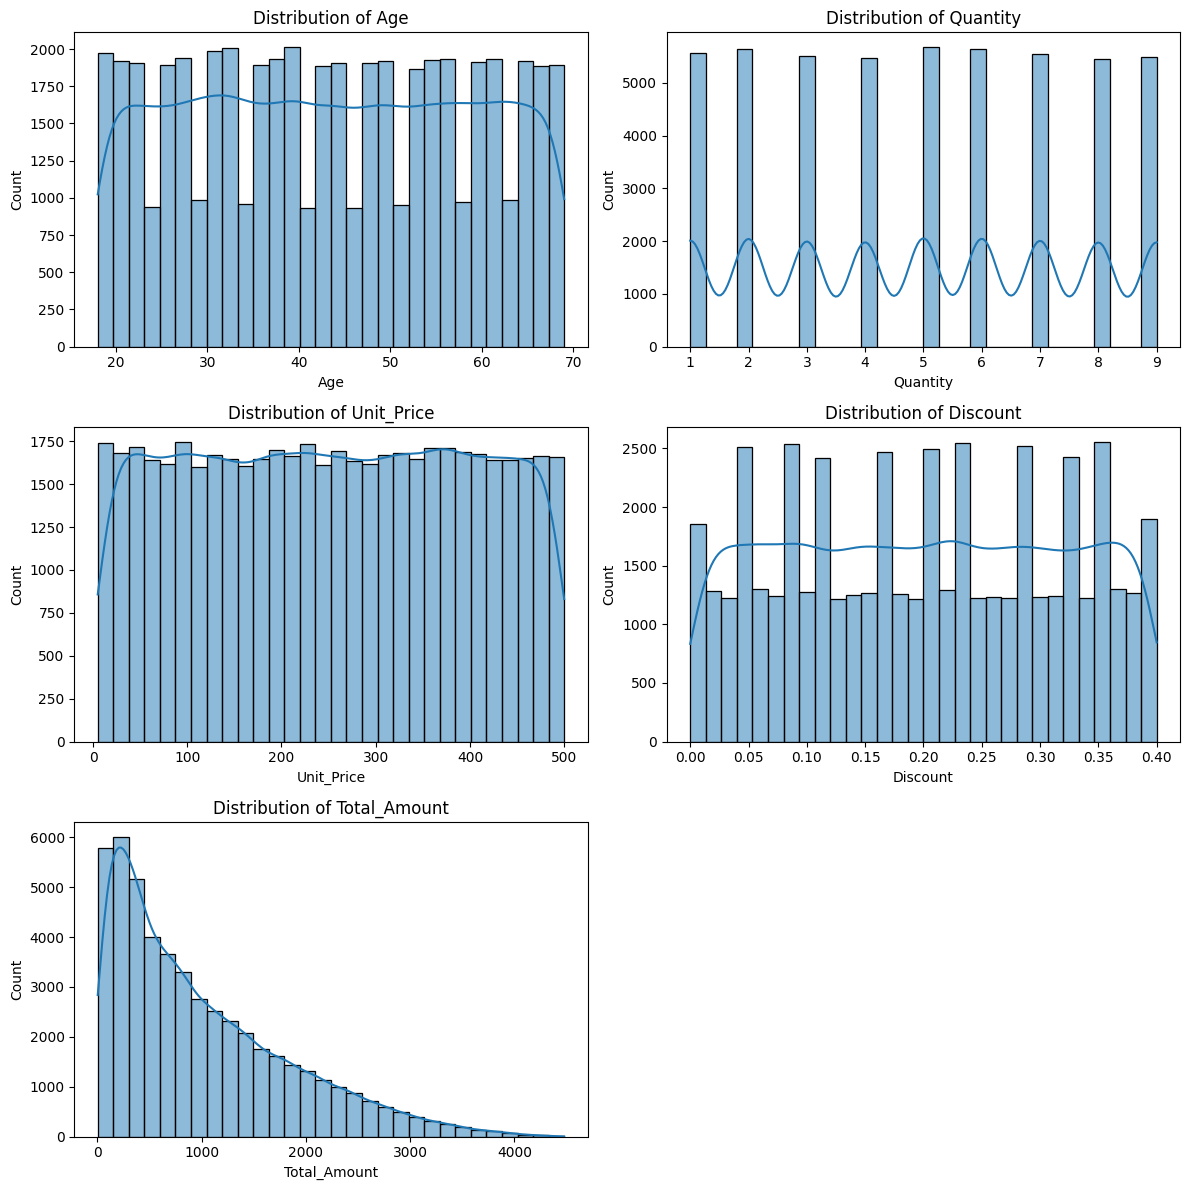

In [ ]:
n = len(num_cols)
rows = int(np.ceil(n / 2))
cols = 2

plt.figure(figsize=(12, rows * 4))
for i, col in enumerate(num_cols, 1):
    plt.subplot(rows, cols, i)
    sns.histplot(df[col], bins=30, kde=True)
    plt.title(f"Distribution of {col}")
plt.tight_layout()
plt.show()

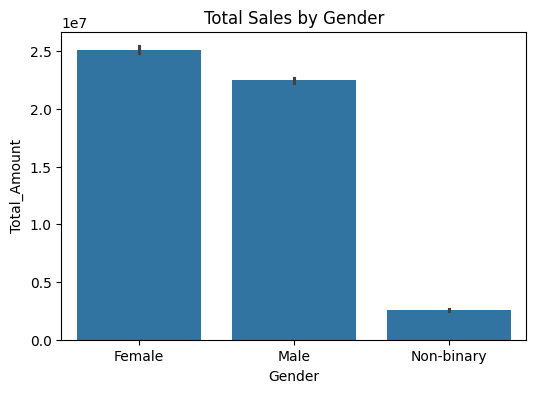

In [ ]:
# Gender-wise total sales
plt.figure(figsize=(6, 4))
sns.barplot(x='Gender', y='Total_Amount', data=df, estimator=sum)
plt.title('Total Sales by Gender')
plt.show()


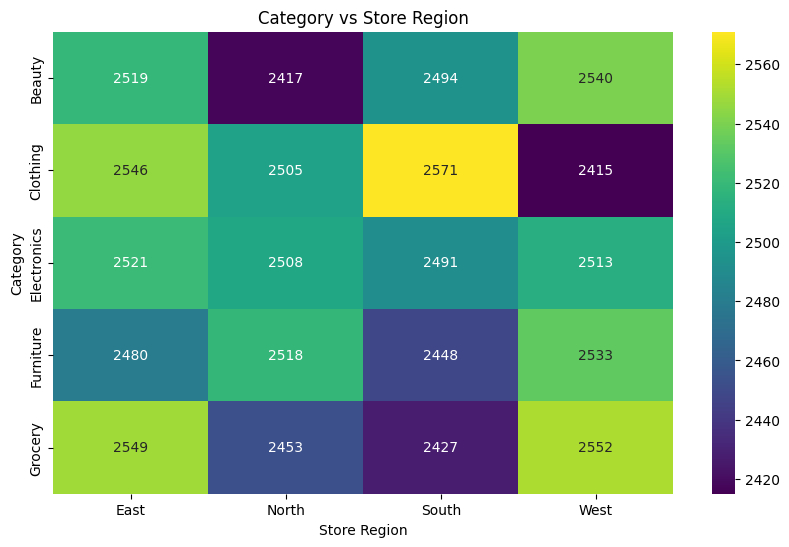

In [5]:
# Plotting a heatmap of Category vs Store_Region
plt.figure(figsize=(10, 6))
sns.heatmap(pd.crosstab(df['Category'], df['Store_Region']), annot=True, fmt='d', cmap='viridis')
plt.title('Category vs Store Region')
plt.xlabel('Store Region')
plt.ylabel('Category')
plt.show()

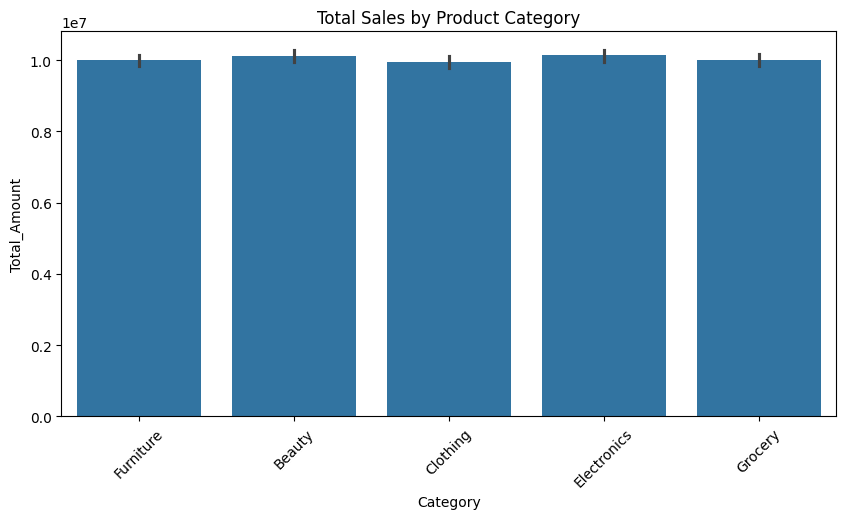

In [ ]:


# Product Category vs Total Amount
plt.figure(figsize=(10, 5))
sns.barplot(x='Category', y='Total_Amount', data=df, estimator=sum)
plt.title('Total Sales by Product Category')
plt.xticks(rotation=45)
plt.show()

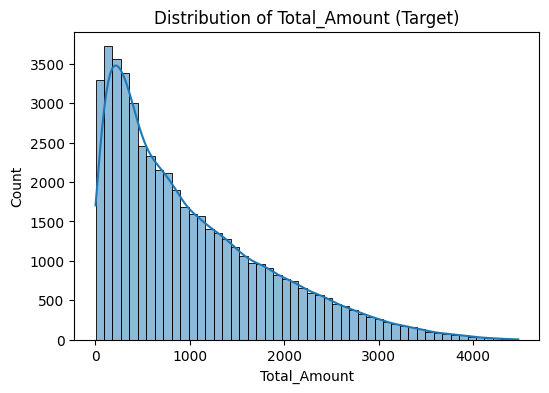

Skewness: 1.0591181358737012


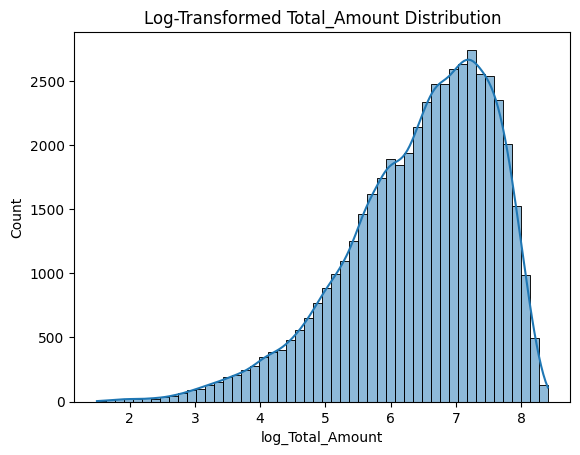

In [ ]:
plt.figure(figsize=(6,4))
sns.histplot(df['Total_Amount'], bins=50, kde=True)
plt.title("Distribution of Total_Amount (Target)")
plt.show()

print("Skewness:", df['Total_Amount'].skew())

# Optional transformation preview
df['log_Total_Amount'] = np.log1p(df['Total_Amount'])
sns.histplot(df['log_Total_Amount'], bins=50, kde=True)
plt.title("Log-Transformed Total_Amount Distribution")
plt.show()


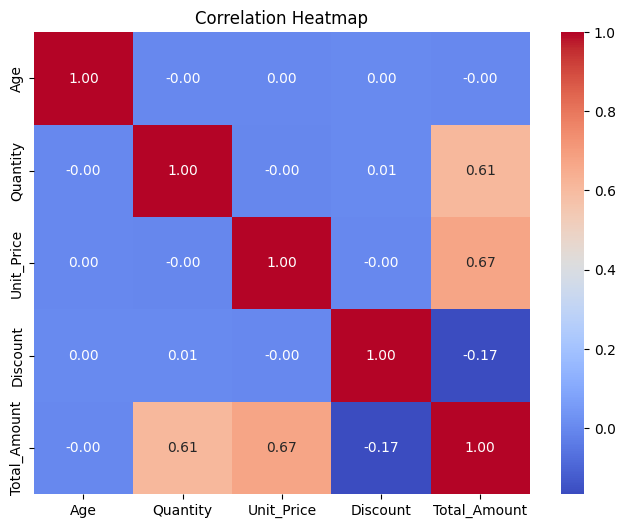

In [ ]:

# Correlation heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(df[num_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Heatmap")
plt.show()

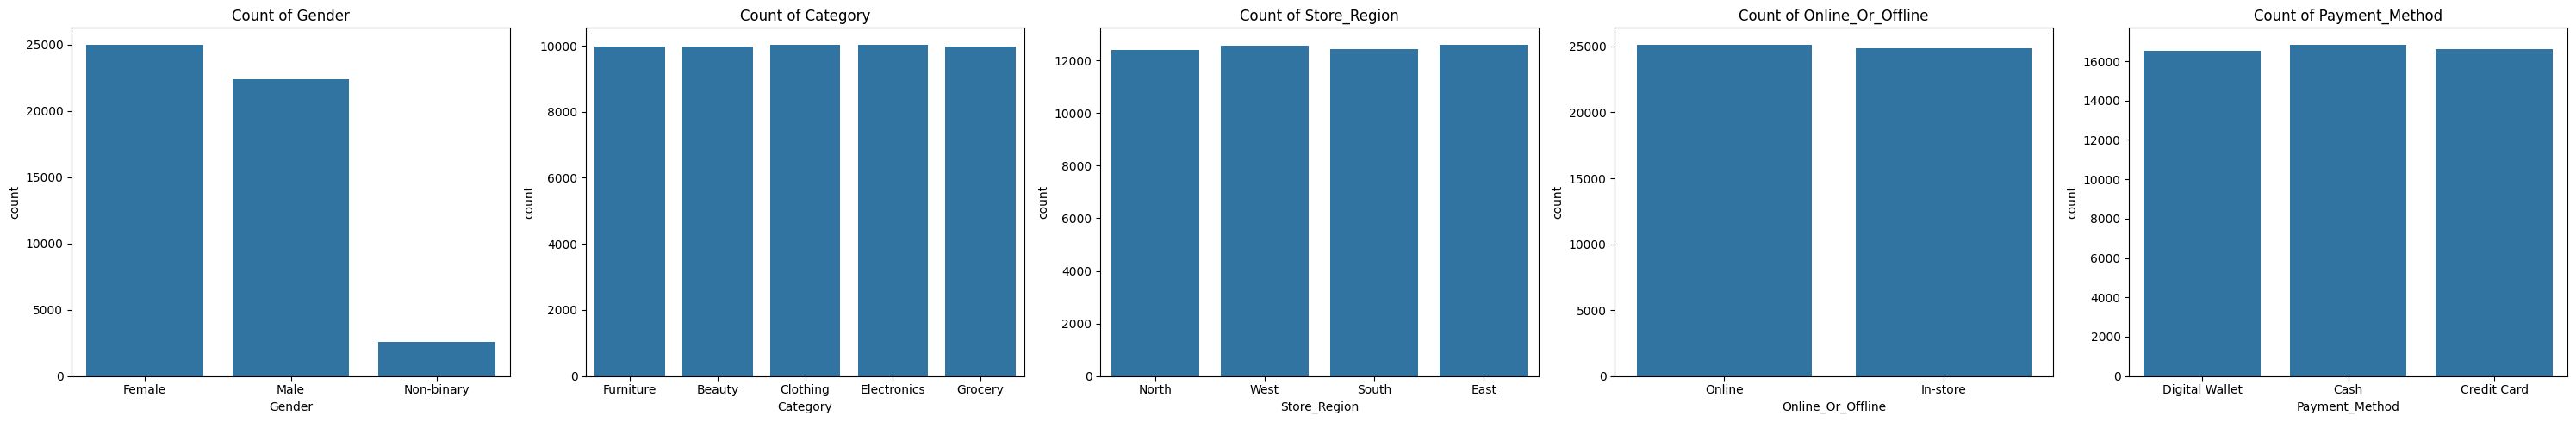

In [ ]:
# Count plots for categorical features
cat_cols = ['Gender', 'Category', 'Store_Region', 'Online_Or_Offline', 'Payment_Method']

plt.figure(figsize=(30, 5))
for i, col in enumerate(cat_cols, 1):
    plt.subplot(1, len(cat_cols), i)
    sns.countplot(data=df, x=col)
    plt.title(f"Count of {col}")
plt.tight_layout()
plt.show()


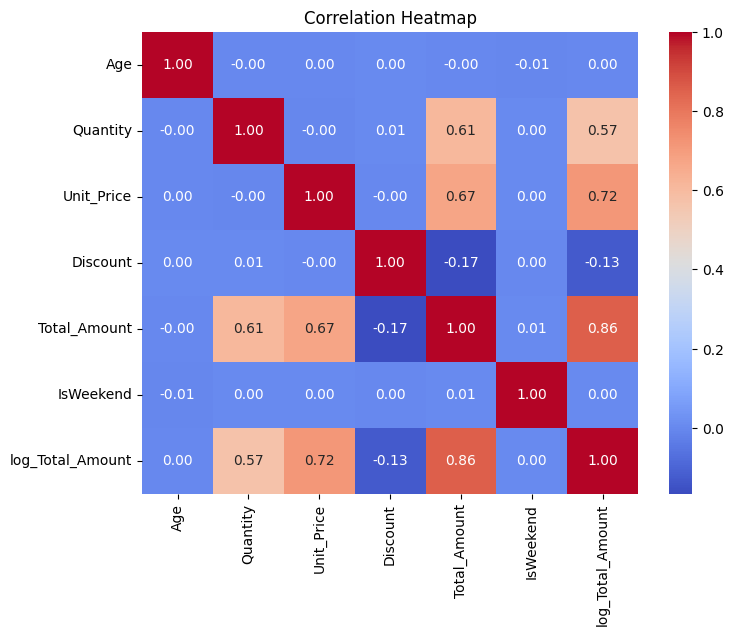

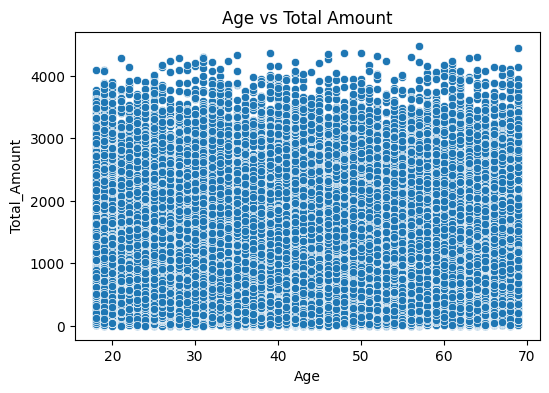

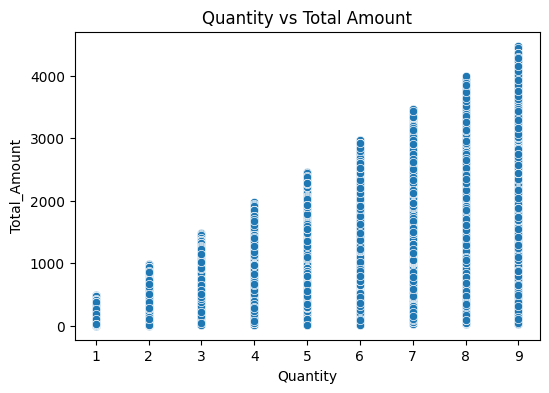

In [ ]:
# Correlation heatmap (numerical only)
plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

# Age vs Total Amount
plt.figure(figsize=(6, 4))
sns.scatterplot(x='Age', y='Total_Amount', data=df)
plt.title("Age vs Total Amount")
plt.show()

# Quantity vs Total Amount
plt.figure(figsize=(6, 4))
sns.scatterplot(x='Quantity', y='Total_Amount', data=df)
plt.title("Quantity vs Total Amount")
plt.show()


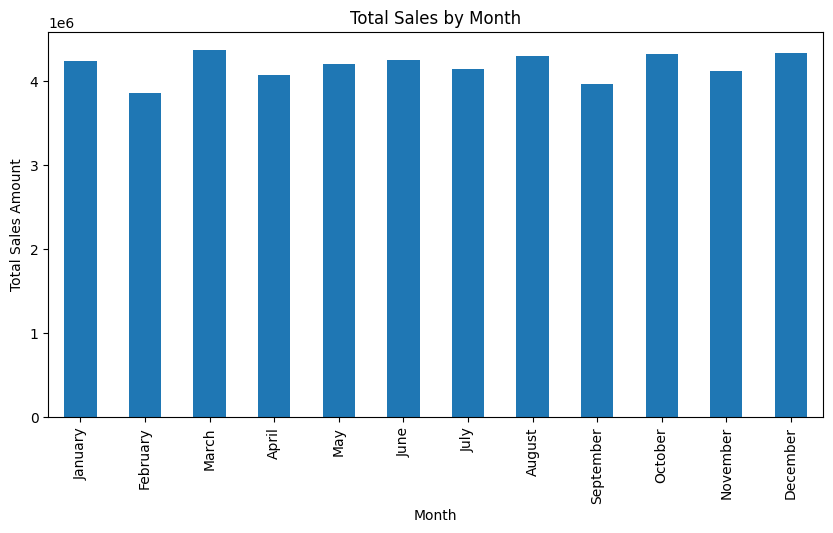

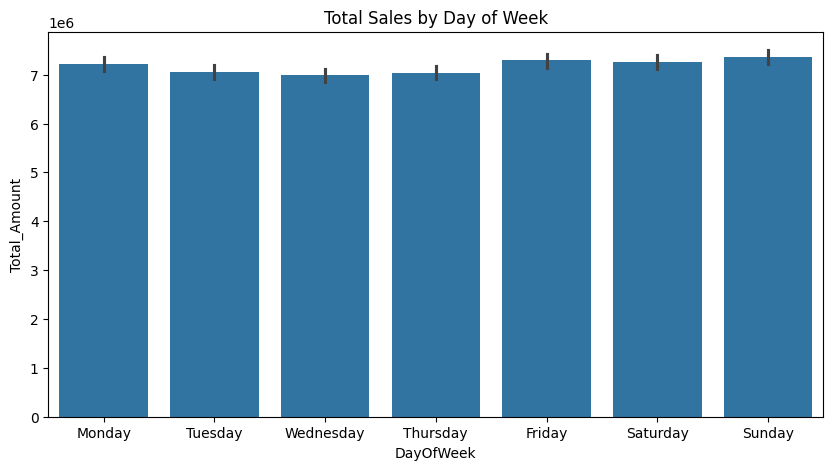

In [ ]:
# Sales trend over time
monthly_sales = df.groupby('Month')['Total_Amount'].sum()
month_order = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']
monthly_sales = monthly_sales.reindex(month_order)
monthly_sales.plot(kind='bar', figsize=(10,5), title='Total Sales by Month')
plt.xlabel("Month")
plt.ylabel("Total Sales Amount")
plt.show()

# Average daily sales pattern
plt.figure(figsize=(10, 5))
sns.barplot(x='DayOfWeek', y='Total_Amount', data=df, estimator='sum', order=['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday'])
plt.title("Total Sales by Day of Week")
plt.show()

In [ ]:
import plotly.express as px
import plotly.graph_objects as go
from pandas.tseries.holiday import USFederalHolidayCalendar
import pandas as pd

monthly = df.groupby([df['Date'].dt.year.rename('year'), df['Date'].dt.month.rename('month')]).agg(
    total_sales=('Total_Amount','sum'),
    # transactions=('Transaction_ID','nunique') # Transaction_ID was dropped
).reset_index()

monthly['ym'] = pd.to_datetime(monthly[['year','month']].assign(day=1))
monthly = monthly.sort_values('ym')

all_months = pd.date_range(start=monthly['ym'].min(), end=monthly['ym'].max(), freq='MS')
monthly_full = pd.DataFrame({'ym': all_months})
monthly_full = monthly_full.merge(monthly, on='ym', how='left').fillna(0)

cal = USFederalHolidayCalendar()
holidays = cal.holidays(start=monthly_full['ym'].min(), end=monthly_full['ym'].max())

monthly_full['has_holiday'] = monthly_full['ym'].apply(
    lambda d: any((h.year == d.year and h.month == d.month) for h in holidays)
)

top_spike_months = monthly_full.sort_values('total_sales', ascending=False).head(3)

fig = px.line(
    monthly_full,
    x='ym',
    y='total_sales',
    markers=True,
    title='Monthly Total Sales with Holiday Highlights',
    labels={'ym': 'Month', 'total_sales': 'Total Sales'},
    template='plotly_white'
)


for _, row in top_spike_months.iterrows():
    fig.add_annotation(
        x=row['ym'],
        y=row['total_sales'],
        text=f"Spike<br>{row['ym'].strftime('%b %Y')}",
        showarrow=True,
        arrowhead=2,
        ax=0,
        ay=-40,
        bgcolor='rgba(255,230,0,0.7)',
        bordercolor='black',
        font=dict(size=10)
    )

for date in holidays:
    date_py = pd.Timestamp(date).to_pydatetime()
    fig.add_shape(
        type='line',
        x0=date_py, x1=date_py,
        y0=0, y1=1,
        xref='x', yref='paper',
        line=dict(color='rgba(255,0,0,0.3)', width=2, dash='dot')
    )
    # Optional label above each line
    fig.add_annotation(
        x=date_py,
        yref='paper', y=1.02,
        showarrow=False,
        text=date_py.strftime('%b %d'),
        font=dict(size=9, color='red')
    )

holiday_months = monthly_full[monthly_full['has_holiday']]
fig.add_trace(go.Scatter(
    x=holiday_months['ym'],
    y=holiday_months['total_sales'],
    mode='markers',
    marker=dict(size=10, color='red', symbol='circle'),
    name='Holiday Month'
))

fig.update_traces(mode='lines+markers', line=dict(width=3), marker=dict(size=6))
fig.update_layout(
    hovermode='x unified',
    xaxis=dict(tickformat='%b %Y'),
    yaxis_title='Total Sales',
    title_x=0.5,
    width=950,
    height=500,
    legend_title_text=''
)

fig.show()

Unit_Price: 0 outliers detected


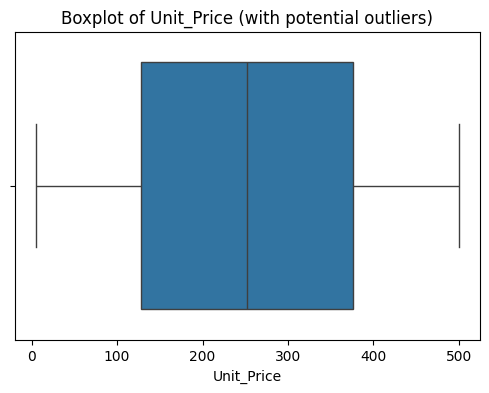

Quantity: 0 outliers detected


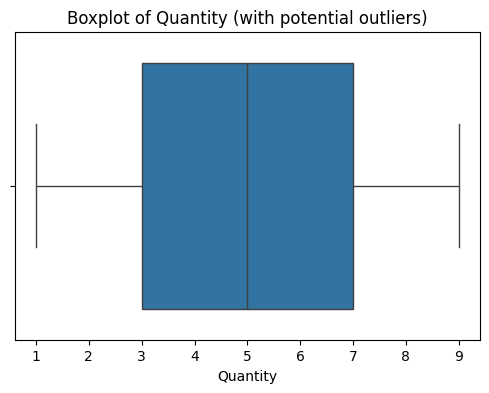

Total_Amount: 907 outliers detected


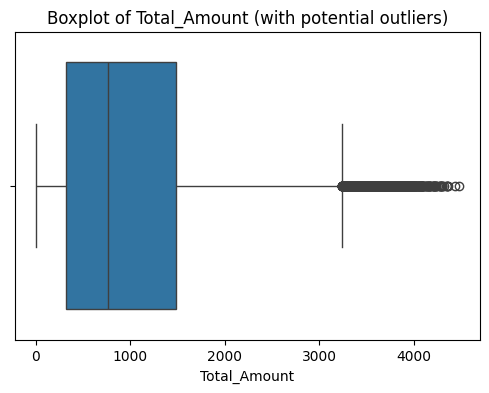

In [ ]:
# Outlier detection using the IQR method
import numpy as np

numeric_cols = ['Unit_Price', 'Quantity', 'Total_Amount']

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    print(f"{col}: {len(outliers)} outliers detected")

    # Optional: visualize
    plt.figure(figsize=(6, 4))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col} (with potential outliers)")
    plt.show()


In [ ]:
# Cap outliers
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df[col] = np.where(df[col] < lower_bound, lower_bound,
                       np.where(df[col] > upper_bound, upper_bound, df[col]))

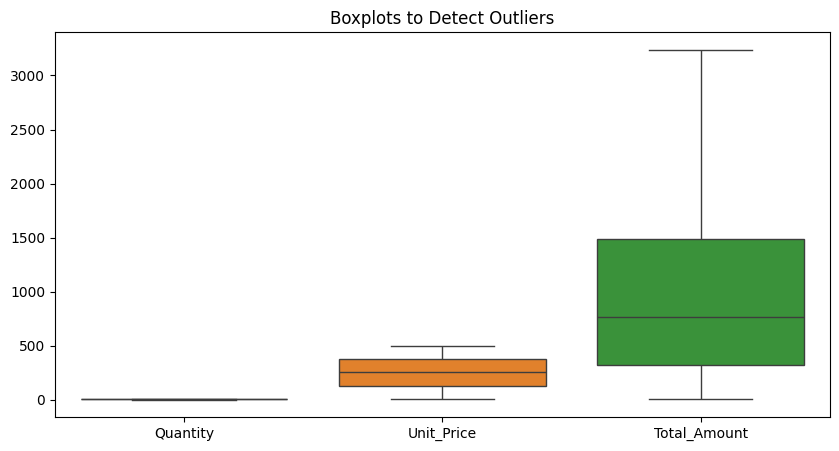

In [ ]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df[['Quantity', 'Unit_Price', 'Total_Amount']])
plt.title("Boxplots to Detect Outliers")
plt.show()

In [ ]:
df = df.drop(columns=[ 'log_Total_Amount', 'Date'])

In [ ]:
# Import libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import numpy as np

# Define target and features
target = 'Total_Amount'
X = df.drop(columns=[target])
y = df[target]

# Identify categorical and numerical columns
cat_cols = X.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()
num_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

print("📊 Categorical columns:", cat_cols)
print("🔢 Numerical columns:", num_cols)

# Split data first (to avoid data leakage)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("\n✅ Train/Test shapes:")
print("Train:", X_train.shape)
print("Test:", X_test.shape)

# Preprocessing pipeline
# - OneHotEncode categorical features
# - Scale numeric features
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
    ]
)

# Transform training and test data
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("\n✅ Encoded feature matrix shapes:")
print("X_train_processed:", X_train_processed.shape)
print("X_test_processed:", X_test_processed.shape)


📊 Categorical columns: ['Gender', 'Category', 'Store_Region', 'Online_Or_Offline', 'Payment_Method', 'DayOfWeek', 'Month', 'IsWeekend']
🔢 Numerical columns: ['Age', 'Quantity', 'Unit_Price', 'Discount']

✅ Train/Test shapes:
Train: (40000, 12)
Test: (10000, 12)

✅ Encoded feature matrix shapes:
X_train_processed: (40000, 42)
X_test_processed: (10000, 42)


In [ ]:
# Get feature names after one-hot encoding
encoded_cols = preprocessor.named_transformers_['cat'].get_feature_names_out(cat_cols)
all_features = np.concatenate([num_cols, encoded_cols])

print("🧠 Total features after encoding:", len(all_features))
print("Sample feature names:\n", all_features[:20])


🧠 Total features after encoding: 42
Sample feature names:
 ['Age' 'Quantity' 'Unit_Price' 'Discount' 'Gender_Female' 'Gender_Male'
 'Gender_Non-binary' 'Category_Beauty' 'Category_Clothing'
 'Category_Electronics' 'Category_Furniture' 'Category_Grocery'
 'Store_Region_East' 'Store_Region_North' 'Store_Region_South'
 'Store_Region_West' 'Online_Or_Offline_In-store'
 'Online_Or_Offline_Online' 'Payment_Method_Cash'
 'Payment_Method_Credit Card']


In [ ]:
df['calc_amount'] = df['Quantity'] * df['Unit_Price'] * (1 - df['Discount'])
df[['Total_Amount', 'calc_amount']].corr()


,Total_Amount,calc_amount
Total_Amount,1.000000,0.997856
calc_amount,0.997856,1.000000


In [ ]:
leakage_cols = ['Quantity', 'Unit_Price', 'Discount']
X = df.drop(columns=['Total_Amount'] + leakage_cols )
y = df['Total_Amount']


In [ ]:
X = df[['Gender', 'Age', 'Category', 'Store_Region',
        'Online_Or_Offline', 'Payment_Method',
        'DayOfWeek', 'Month', 'IsWeekend']]


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

cat_cols = ['Gender', 'Category', 'Store_Region', 'Online_Or_Offline', 'Payment_Method', 'DayOfWeek', 'Month', 'IsWeekend']
num_cols = ['Age']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

preprocessor = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols),
    ('num', 'passthrough', num_cols)
])

model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(random_state=42, n_estimators=200, max_depth=10))
])

model.fit(X_train, y_train)
y_pred = model.predict(X_test)


In [ ]:
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print(f"R2: {r2:.4f}")
print(f"MAE: {mae:.2f}")
print(f"MSE: {mse:.2f}")
print(f"RMSE: {rmse:.2f}")


R2: -0.0030
MAE: 676.86
MSE: 683491.15
RMSE: 826.74


In [ ]:
# Import required libraries
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Define a function to train, predict, and evaluate models
def evaluate_model(model, X_train, y_train, X_test, y_test):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)

    return {'Model': type(model).__name__, 'R2': r2, 'MAE': mae, 'MSE': mse, 'RMSE': rmse}
# Create pipeline
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(random_state=42))
])

# Initialize models
models = [
    LinearRegression(),
    DecisionTreeRegressor(random_state=42),
    RandomForestRegressor(n_estimators=100, random_state=42),
    GradientBoostingRegressor(random_state=42),
    XGBRegressor(n_estimators=200, learning_rate=0.1, random_state=42, verbosity=0)
]

# Evaluate each model
results = []
for model in models:
    print(f"Training {type(model).__name__}...")
    metrics = evaluate_model(model, X_train_processed, y_train, X_test_processed, y_test)
    results.append(metrics)

# Convert results to DataFrame for comparison
results_df = pd.DataFrame(results).sort_values(by='R2', ascending=False)
display(results_df)


Training LinearRegression...
Training DecisionTreeRegressor...
Training RandomForestRegressor...
Training GradientBoostingRegressor...
Training XGBRegressor...


,Model,R2,MAE,MSE,RMSE
2,RandomForestRegressor,0.999872,5.814892,87.373703,9.347390
4,XGBRegressor,0.999775,8.578554,153.004227,12.369488
1,DecisionTreeRegressor,0.999272,14.293536,495.821021,22.267039
3,GradientBoostingRegressor,0.997553,29.266284,1667.774101,40.838390
0,LinearRegression,0.866897,225.500653,90705.535161,301.173596


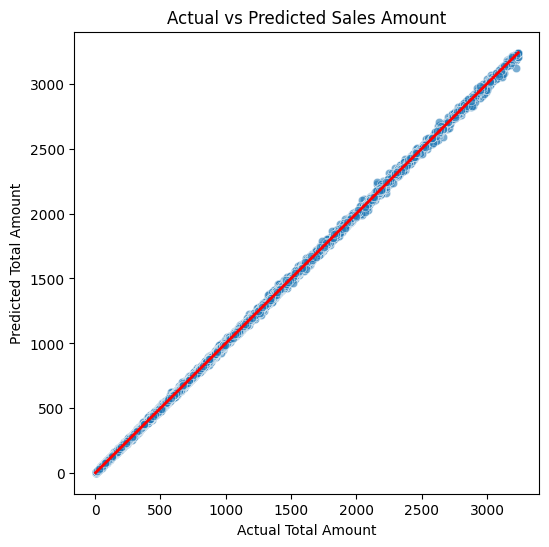

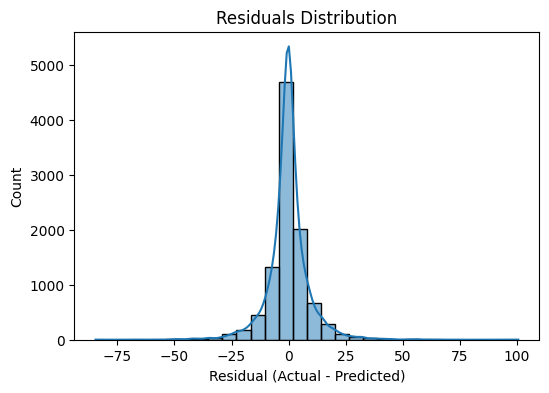

In [ ]:
best_model = RandomForestRegressor(n_estimators=100, random_state=42)
best_model.fit(X_train_processed, y_train)
y_pred = best_model.predict(X_test_processed)

# Actual vs Predicted plot
plt.figure(figsize=(6, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6)
plt.xlabel("Actual Total Amount")
plt.ylabel("Predicted Total Amount")
plt.title("Actual vs Predicted Sales Amount")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', lw=2)
plt.show()

# Residuals plot
residuals = y_test - y_pred
plt.figure(figsize=(6, 4))
sns.histplot(residuals, bins=30, kde=True)
plt.title("Residuals Distribution")
plt.xlabel("Residual (Actual - Predicted)")
plt.show()


In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'max_features': ['sqrt', 'log2', 0.5]
}

rf = RandomForestRegressor(random_state=42, n_jobs=-1)
random_search = RandomizedSearchCV(rf, param_distributions=param_grid, n_iter=20,
                                   cv=3, scoring='neg_root_mean_squared_error',
                                   random_state=42, n_jobs=-1)
random_search.fit(X_train_processed, y_train)

print("Best parameters:", random_search.best_params_)
print("Best RMSE:", (-random_search.best_score_)**0.5)
best_rf = random_search.best_estimator_


In [ ]:
# Extract feature importance
feature_names = preprocessor.named_transformers_['cat'].get_feature_names_out(cat_cols)
all_features = np.concatenate([num_cols, feature_names])

importances = best_model.feature_importances_
feat_imp = pd.DataFrame({'Feature': all_features, 'Importance': importances})
feat_imp = feat_imp.sort_values(by='Importance', ascending=False).head(15)

# Plot
plt.figure(figsize=(8, 5))
sns.barplot(x='Importance', y='Feature', data=feat_imp, palette='viridis')
plt.title("Top 15 Important Features")
plt.show()


In [ ]:
# Residuals vs Predicted
y_pred = best_rf.predict(X_test_processed)
plt.figure(figsize=(6,4))
sns.scatterplot(x=y_pred, y=y_test - y_pred, alpha=0.5)
plt.axhline(0, color='red', linestyle='--')
plt.title("Residuals vs Predicted")
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.show()

# Combine metrics into summary table
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Decision Tree', 'Random Forest', 'XGBoost', 'Gradient Boosting'],
    'R2': [r2_lr, r2_dt, r2_rf, r2_xgb, r2_gb],
    'MAE': [mae_lr, mae_dt, mae_rf, mae_xgb, mae_gb],
    'RMSE': [rmse_lr, rmse_dt, rmse_rf, rmse_xgb, rmse_gb]
})
results.to_csv('model_performance_summary.csv', index=False)
results


In [ ]:
from sklearn.inspection import permutation_importance

perm = permutation_importance(best_rf, X_test_processed, y_test, n_repeats=10, random_state=42, n_jobs=-1)
perm_df = pd.DataFrame({
    'feature': all_features,
    'importance_mean': perm.importances_mean
}).sort_values('importance_mean', ascending=False)

plt.figure(figsize=(8,6))
sns.barplot(x='importance_mean', y='feature', data=perm_df.head(15))
plt.title("Top 15 Features by Permutation Importance")
plt.show()
